In [40]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import optimize
import re

In [41]:
def load_spectrum(path):
    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []
    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    return np.array(channels), np.array(counts)

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)
    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    if model is None:
        mu = np.sum(c * N) / N_t
        sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t
        return mu, sigma, float('nan')
    return 0, 0, 0

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def linear(x, m, b):
    return m * x + b

electron_mass_ene = 0.5109989461
alpha = 1/137.035999084
c = 299792458

def kurie(energy, counts, Z, sigma_energy=None):
    if sigma_energy is None:
        sigma_ene = np.zeros_like(energy)
    else: sigma_ene = sigma_energy
    energy_total = energy + electron_mass_ene
    p_times_c = np.sqrt(energy**2 + 2*energy*electron_mass_ene)
    sigma_p_times_c = (energy + electron_mass_ene) / p_times_c * sigma_ene

    #fermi
    beta = p_times_c / energy_total
    sigma_beta = np.sqrt((sigma_p_times_c / energy_total)**2 + (p_times_c * sigma_ene / energy_total**2)**2)
    x = 2 * np.pi * alpha * Z / beta
    sigma_x = x * sigma_beta / beta
    F = x / (1 - np.exp(-x))
    sigma_F = (np.exp(x) * (np.exp(x) - x - 1))/(np.exp(x)-1)**2 * sigma_x

    #kurie

    K = np.sqrt(counts / (p_times_c * energy_total * F))
    sigma_K = 0.5 * K * np.sqrt((sigma_p_times_c / p_times_c)**2 + (sigma_ene / energy_total)**2 + (sigma_F / F)**2)

    return K, sigma_K

M_CALIB = 0.0046302226
B_CALIB = 0.0119470133
M_CALIB_SIGMA = 0.0003230098
B_CALIB_SIGMA = 0.0050527639

def calib(channels, sigma_channels=None):
    energy = linear(channels, M_CALIB, B_CALIB)
    if sigma_channels is not None:
        sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + (M_CALIB * sigma_channels)**2 + B_CALIB_SIGMA**2)
    else:
         sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + B_CALIB_SIGMA**2)
    return energy, sigma_energy

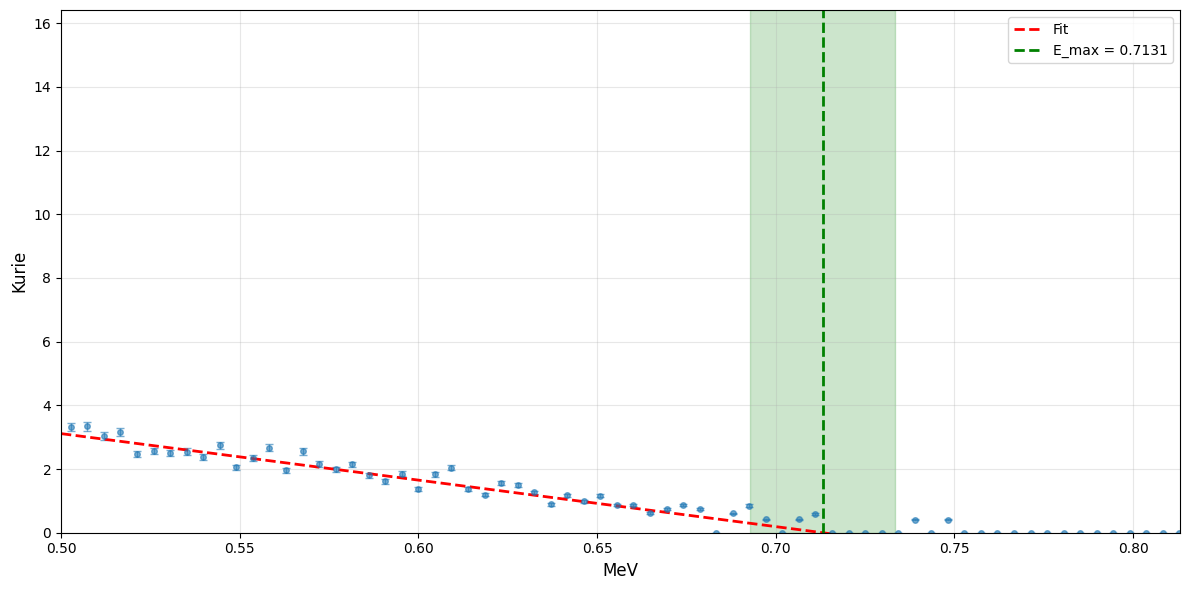

χ² = 0.031320
E_max = 0.7131 ± 0.0203 MeV


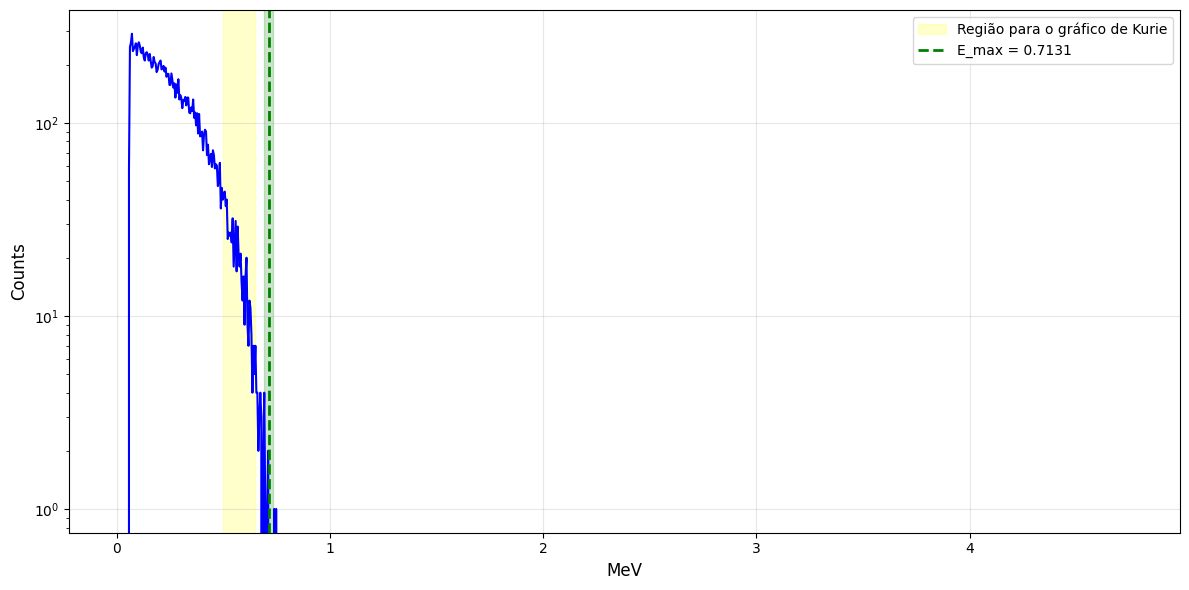

In [42]:
Z = 82 
channels_tl2, counts_tl2 = load_spectrum('TLSINV.ASC')
energies_tl2, sigma_energies_tl2 = calib(channels_tl2)

tl2_roi_min, tl2_roi_max = 0.50, 0.65
tl2_roi = (energies_tl2 >= tl2_roi_min) & (energies_tl2 <= tl2_roi_max)

kurie_tl2, sigma_kurie_tl2 = kurie(energies_tl2, counts_tl2, Z, sigma_energy=sigma_energies_tl2)

popt, pcovt = optimize.curve_fit(linear, energies_tl2[tl2_roi], kurie_tl2[tl2_roi], sigma=sigma_kurie_tl2[tl2_roi], p0=[-2, 1], absolute_sigma=True)
perr = np.sqrt(np.diag(pcovt))

energy_max_tl2 = -popt[1] / popt[0]
sigma_energy_max_tl2 = np.sqrt((perr[1] / popt[0])**2 + (popt[1] * perr[0] / popt[0]**2)**2)

chi2_red = compute_chi2(kurie_tl2[tl2_roi], linear(energies_tl2[tl2_roi], *popt), dof=len(energies_tl2[tl2_roi])-2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(energies_tl2, kurie_tl2, yerr=sigma_kurie_tl2, fmt='o', markersize=4, capsize=3, elinewidth=1, alpha=0.6)
E_kurie = np.linspace(tl2_roi_min, energy_max_tl2 + 0.1, 100)
#E_kurie = np.linspace(tl2_roi_min, tl2_roi_max, 100)
ax.plot(E_kurie, linear(E_kurie, *popt), 'r--', linewidth=2, label='Fit')
ax.axvline(energy_max_tl2, color='green', linestyle='--', linewidth=2, label=f'E_max = {energy_max_tl2:.4f}')
ax.axvspan(energy_max_tl2 - sigma_energy_max_tl2, energy_max_tl2 + sigma_energy_max_tl2, alpha=0.2, color='green')
ax.set_xlim(tl2_roi_min, energy_max_tl2 + 0.1)
ax.set_ylim(bottom=0)
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('Kurie', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"χ² = {chi2_red:.6f}")
print(f"E_max = {energy_max_tl2:.4f} ± {sigma_energy_max_tl2:.4f} MeV")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies_tl2, counts_tl2, 'b-', linewidth=1.5)
ax.axvspan(tl2_roi_min, tl2_roi_max, alpha=0.2, color='yellow', label='Região para o gráfico de Kurie')
ax.axvline(energy_max_tl2, color='green', linestyle='--', linewidth=2, label=f'E_max = {energy_max_tl2:.4f}')
ax.axvspan(energy_max_tl2 - sigma_energy_max_tl2, energy_max_tl2 + sigma_energy_max_tl2, alpha=0.2, color='green')
ax.set_yscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()